# 04 — Modelagem

**Objetivo:** Selecionar o número de clusters por quatro métricas (cotovelo, Silhouette, Davies-Bouldin, Calinski-Harabasz) → k=6, montar e fitar o `pipeline_final` (preprocessor → KMeans) e salvar o artefato único de deploy.

**Inputs:** `data/processed/X_scaled.parquet, data/processed/X_completo.parquet`

**Outputs:** `pipeline_final.joblib, dados_clusterizados.parquet`

---

**Roteiro:**

1. Setup, tema e configurações locais e globais
2. Carregamendo dos dado
3. Varredura de k: cotovelo + silhouette + Davies-Bouldin + Calinski-Harabasz
4. Montar e fitar o pipeline_final
5. Salvar artefatos
6. Fechamento

### Etapa 1 — Setup, tema e configurações locais e globais

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.config import CONFIG, CAMINHOS
from src.viz_config import PALETTE, CORES

DADOS_PRO    = CAMINHOS.dados_processed
MODELS_DIR   = CAMINHOS.modelos
FIG_DIR  = CAMINHOS.figures
RANDOM_STATE = CONFIG["dados"]["random_state"]

print("✅ Setup OK\n")
print(f"DADOS_PRO   : {DADOS_PRO}")
print(f"MODELS_DIR  : {MODELS_DIR}")
print(f"FIG_DIR     : {FIG_DIR}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

✅ Setup OK

DADOS_PRO   : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\data\processed
MODELS_DIR  : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\models
FIG_DIR     : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\reports\figures
RANDOM_STATE: 42


### Etapa 2 - Carregamendo dos dados

Vamos carregar dois objetos com papéis distintos:

- `features_scaled.parquet` - as 3 colunas já escaladas. É sobre estes dados que a varredura de cotovelo/silhouette vai rodar, garantindo que a métrica de k reflita exatamente o que o KMeans enxerga dentro do pipeline.
- `dados_limpos.parquet` -  (RAW, 4 colunas) — guardado pra mais tarde, quando montarmos o pipeline_final e fitarmos ponta a ponta no completo (preprocessor + KMeans juntos).

In [2]:
X_scaled = pd.read_parquet(DADOS_PRO / "features_scaled.parquet")
X_completo = pd.read_parquet(DADOS_PRO / "dados_limpos.parquet")

print(f"X_scaled   (p/ escolha de k):   {X_scaled.shape}  cols={list(X_scaled.columns)}")
print(f"X_completo (p/ pipeline_final): {X_completo.shape}  cols={list(X_completo.columns)}\n")

X_scaled.head()

X_scaled   (p/ escolha de k):   (200, 3)  cols=['idade', 'renda_anual', 'score_gasto']
X_completo (p/ pipeline_final): (200, 4)  cols=['genero', 'idade', 'renda_anual', 'score_gasto']



,idade,renda_anual,score_gasto
id_cliente,,,
1,-1.424569,-1.738999,-0.434801
2,-1.281035,-1.738999,1.195704
3,-1.352802,-1.700830,-1.715913
4,-1.137502,-1.700830,1.040418
5,-0.563369,-1.662660,-0.395980


### Etapa 3 — Varredura de k: cotovelo + silhouette + Davies-Bouldin + Calinski-Harabasz

Vamos realizar uma varredura no k indo de 2 até 10...

In [3]:
K_RANGE = range(2, 11)
resultados = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    resultados.append({
        "k":        k,
        "inercia":  km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
    })

res = pd.DataFrame(resultados).set_index("k")

print("═" * 72)
print("VARREDURA DE k  (melhor: ↑silhouette ↑CH ↓DB ↓inércia-no-cotovelo)")
print("═" * 72)
print(res.round(3).to_string())

════════════════════════════════════════════════════════════════════════
VARREDURA DE k  (melhor: ↑silhouette ↑CH ↓DB ↓inércia-no-cotovelo)
════════════════════════════════════════════════════════════════════════
    inercia  silhouette  davies_bouldin  calinski_harabasz
k                                                         
2   389.386       0.335           1.261            107.096
3   295.212       0.358           1.050            101.695
4   205.225       0.404           0.931            125.676
5   168.248       0.417           0.875            125.101
6   133.868       0.428           0.825            135.102
7   117.012       0.417           0.793            132.774
8   103.873       0.408           0.892            131.006
9    93.093       0.418           0.820            130.004
10   82.385       0.407           0.868            132.638


In [4]:
print("\n   Ótimos por métrica:")
print(f"   • Silhouette (máx)        → k={res['silhouette'].idxmax()}")
print(f"   • Davies-Bouldin (mín)    → k={res['davies_bouldin'].idxmin()}")
print(f"   • Calinski-Harabasz (máx) → k={res['calinski_harabasz'].idxmax()}")


   Ótimos por métrica:
   • Silhouette (máx)        → k=6
   • Davies-Bouldin (mín)    → k=7
   • Calinski-Harabasz (máx) → k=6


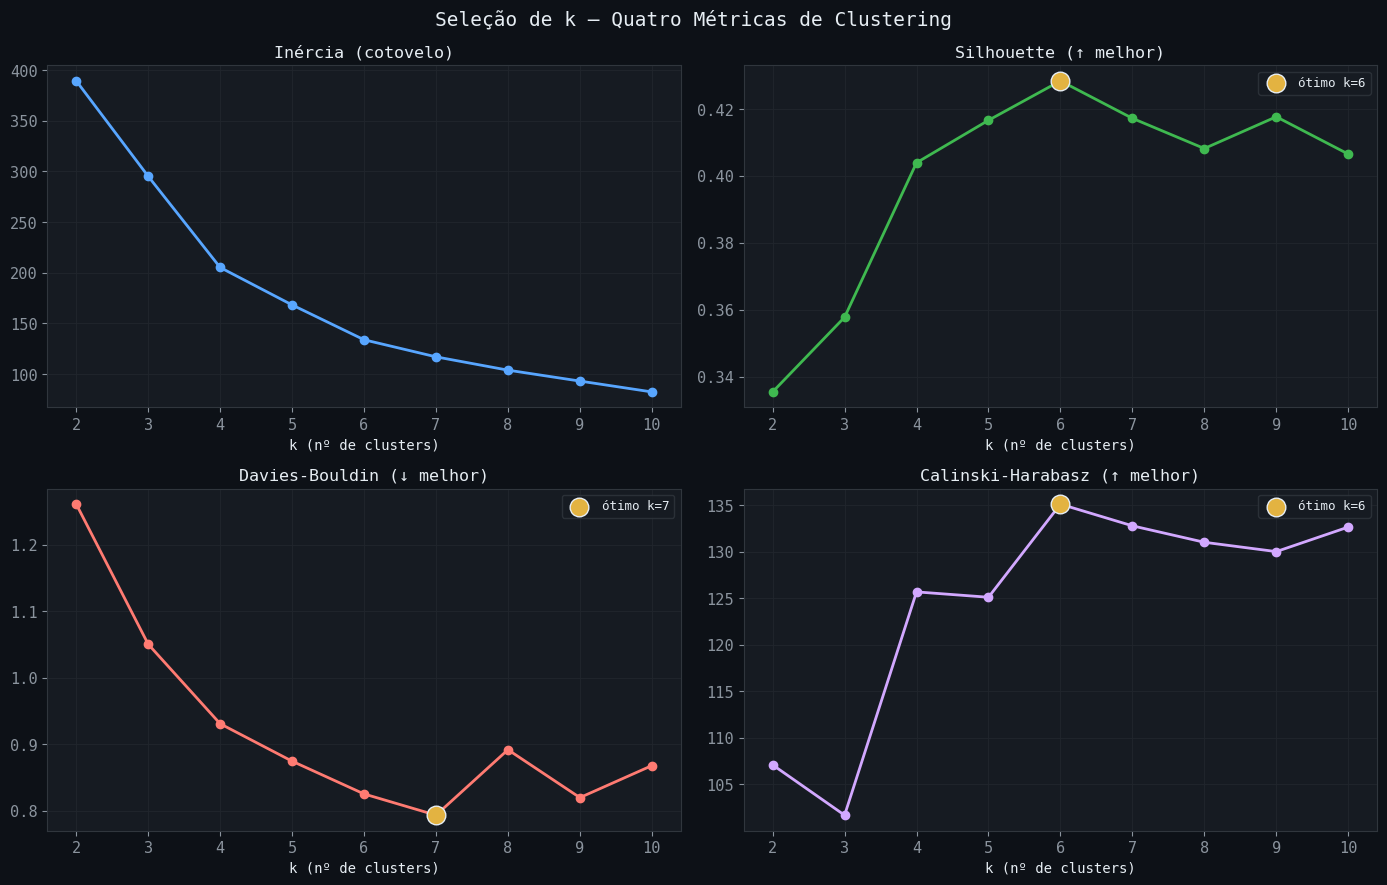

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ks = list(K_RANGE)

specs = [
    ("inercia",            "Inércia (cotovelo)",        PALETTE[0], "min"),
    ("silhouette",         "Silhouette (↑ melhor)",     PALETTE[2], "max"),
    ("davies_bouldin",     "Davies-Bouldin (↓ melhor)", PALETTE[1], "min"),
    ("calinski_harabasz",  "Calinski-Harabasz (↑ melhor)", PALETTE[3], "max"),
]

for ax, (col, titulo, cor, sentido) in zip(axes.flat, specs):
    ax.plot(ks, res[col], color=cor, marker="o", linewidth=2)
    ax.set_xlabel("k (nº de clusters)")
    ax.set_title(titulo)
    ax.set_xticks(ks)
    
    if sentido == "max":
        k_opt = res[col].idxmax()
        ax.scatter([k_opt], [res[col].max()], color=CORES["amarelo"],
                   s=180, zorder=5, edgecolor=CORES["texto"],
                   label=f"ótimo k={k_opt}")
        ax.legend()
    elif col == "davies_bouldin":
        k_opt = res[col].idxmin()
        ax.scatter([k_opt], [res[col].min()], color=CORES["amarelo"],
                   s=180, zorder=5, edgecolor=CORES["texto"],
                   label=f"ótimo k={k_opt}")
        ax.legend()

plt.suptitle("Seleção de k — Quatro Métricas de Clustering", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb04_selecao_k.png", dpi=120, bbox_inches="tight")
plt.show() 

Temos uma pequena sutileza nas análises dos valores de k em relação ao que o EDA sugeria. No scatterplot, conseguimos visualizar 5 clusteres bem separados. Entretanto ao fazer os testes de varredura para k, as métricas convergem para `k=6`:

- Silhouette: pico em k=6 (0.428), com k=5 logo atrás (0.417).
- Calinski-Harabasz: pico claro em k=6 (135.1).
- Davies-Bouldin: ótimo em k=7 (0.793), mas k=6 (0.825) está bem perto — segundo melhor.
- Inércia: o cotovelo é suave (features independentes não geram cotovelo dramático); a maior desaceleração da queda acontece entre k=5 e k=6.

Diante desses fatos, vamos seguir as métricas e escolher `k=6`, seguindo a validação numérica.

### Etapa 4 - Montar e fitar o pipeline_final

Após a definição do pré-processamento e da quantidade ideal de clusters, foi construída a pipeline final de segmentação, composta por:

- etapa de pré-processamento (preprocessor);
- algoritmo `K-Means` configurado com `k = 6` clusters.

A pipeline foi reconstruída integralmente e ajustada de ponta a ponta utilizando o conjunto completo de dados brutos (X_completo), permitindo que todas as etapas fossem executadas de forma integrada e reproduzível.

In [6]:
K_FINAL = 6

COLS_NUMERICAS = ["idade", "renda_anual", "score_gasto"]

preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), COLS_NUMERICAS)],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [7]:
pipeline_final = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)),
    ]
)

pipeline_final.fit(X_completo)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse

In [8]:
print(f"Inércia final : {pipeline_final.named_steps['kmeans'].inertia_:.2f}")

Inércia final : 133.87


Vamos criar um DataFrame com os rótulos de clusters para todos os 200 clientes

In [9]:
labels = pipeline_final.named_steps["kmeans"].labels_

df_clusterizado = X_completo.copy()
df_clusterizado["cluster"] = labels

df_clusterizado.head()

,genero,idade,renda_anual,score_gasto,cluster
id_cliente,,,,,
1,Male,19,15,39,4
2,Male,21,15,81,4
3,Female,20,16,6,5
4,Female,23,16,77,4
5,Female,31,17,40,5


In [10]:
labels_pred = pipeline_final.predict(X_completo)
print(f"{'✅' if (labels_pred == labels).all() else '❌'} "
      f"pipeline.predict(X_completo) reproduz os labels do fit")

✅ pipeline.predict(X_completo) reproduz os labels do fit


### Etapa 5 — Salvar artefatos

Vamos salvar os artefatos gerados no NB04. Temos :

- Artefato único de deploy
- DataFrame clusterizado

In [11]:
CAMINHO_PIPELINE = MODELS_DIR / "pipeline_final.joblib"
joblib.dump(pipeline_final, CAMINHO_PIPELINE)

print("Artefato único de deploy")
print("  models/")
print(f"    pipeline_final.joblib (preprocessor -> KMeans k={K_FINAL})")

Artefato único de deploy
  models/
    pipeline_final.joblib (preprocessor -> KMeans k=6)


In [12]:
CAMINHO_CLUSTERS = DADOS_PRO / "dados_clusterizados.parquet"
df_clusterizado.to_parquet(CAMINHO_CLUSTERS, index=True)

print("DataFrame clusterizado")
print("  data/processed/")
print(f"    dados_clusterizados.parquet {df_clusterizado.shape}  (4 cols + cluster)")

DataFrame clusterizado
  data/processed/
    dados_clusterizados.parquet (200, 5)  (4 cols + cluster)


In [13]:
pipe_check    = joblib.load(CAMINHO_PIPELINE)
labels_reload = pipe_check.predict(X_completo)
idem          = (labels_reload == labels).all()

df_check  = pd.read_parquet(CAMINHO_CLUSTERS)
idx_ok    = df_check.index.name == "id_cliente"
clust_ok  = "cluster" in df_check.columns

print("Verificação round-trip:")
print(f"   {'✅' if idem     else '❌'} pipeline recarregado prediz labels idênticos")
print(f"   {'✅' if idx_ok   else '❌'} índice id_cliente preservado no parquet")
print(f"   {'✅' if clust_ok else '❌'} coluna 'cluster' presente no parquet")

Verificação round-trip:
   ✅ pipeline recarregado prediz labels idênticos
   ✅ índice id_cliente preservado no parquet
   ✅ coluna 'cluster' presente no parquet


### Etapa 6 - Fechamento

`SELEÇÃO DE k (varredura k=2..10 sobre features escaladas)`
- Silhouette        → ótimo k=6 (0.428)
- Calinski-Harabasz → ótimo k=6 (135.1)
- Davies-Bouldin    → ótimo k=7 (k=6 vice, 0.825)
- Inércia           → cotovelo suave perto de k=5/6
- DECISÃO: k=6 (2 de 3 métricas + vice na 3ª)
- Contraria o "5 grupos" do plano 2D → idade revela 6º grupo

`PIPELINE FINAL (artefato único)`
- preprocessor → KMeans(k=6), reconstruído do zero
- Fit ponta a ponta no X_completo (4 cols RAW)
- genero descartado internamente (remainder='drop')
- Inércia final: 133.87
- predict(X_completo) reproduz labels do fit ✅

`DISTRIBUIÇÃO DOS CLUSTERS (saudável, sem grupos degenerados)`
- C0:45 · C1:39 · C2:33 · C3:39 · C4:23 · C5:21

`ARTEFATOS`
- models/
    - pipeline_final.joblib → deploy (round-trip validado)
- data/processed/
    - dados_clusterizados.parquet (200×5) → base do NB05 e app

`PRÓXIMO PASSO → NB05 (Avaliação)`
- 4 métricas finais consolidadas (k=6)
- Perfilização: médias por cluster → nomear personas
- nvestigar o 6º grupo (por que k=6 > k=5)
- Cruzar clusters × genero (perfilização)
- Surrogate DecisionTree → regras interpretáveis por cluster
- Visualização PCA 2D/3D dos clusters